In [2]:
!pip install natasha
!pip install pymorphy2
!pip install matplotlib
!pip install pandas

In [3]:
# Стандартные библиотеки
from collections import Counter

# Библиотеки для визуализации
import matplotlib.pyplot as plt
import pandas as pd

# Лингвистические библиотеки
from natasha import (
    Segmenter,
    MorphVocab,
    NewsMorphTagger,
    NewsSyntaxParser,
    Doc,
    NewsEmbedding
)
from pymorphy2 import MorphAnalyzer

**Инициализация инструментов**

In [4]:
segmenter = Segmenter()
morph_vocab = MorphVocab()
emb = NewsEmbedding()
morph_tagger = NewsMorphTagger(emb)
syntax_parser = NewsSyntaxParser(emb)
morph = MorphAnalyzer()

**Загрузка данных и разбиение текста на предложения**

In [30]:
def load_texts(file_path, max_rows=5000):
    df = pd.read_csv(file_path)

    # Ограничиваем количество строк
    df = df.head(max_rows)

    print(f"Обработано строк из CSV: {len(df)}")

    # Подготовка текстов (используем title и text)
    df['title'] = df['title'].fillna('')
    df['text'] = df['text'].fillna('')
    df['full_text'] = df['title'] + '. ' + df['text']

    # Разбиение на предложения
    sentences = []
    for text in df['full_text']:
        if str(text).strip():
            doc = Doc(str(text))
            doc.segment(segmenter)
            for sent in doc.sents:
                if sent.text.strip():
                    sentences.append(sent.text)

    print(f"Всего предложений: {len(sentences)}")
    return sentences

**Синтаксический разбор предложений**
Поиск подлежащего и сказуемого.

In [31]:
def parse_sentence(sentence, segmenter, morph_tagger, syntax_parser):
    doc = Doc(sentence)
    doc.segment(segmenter)
    doc.tag_morph(morph_tagger)
    doc.parse_syntax(syntax_parser)

    subject = None
    predicate = None

    # Поиск сказуемого (root)
    for token in doc.sents[0].tokens:
        if token.rel == 'root':
            predicate = token
            break

    # Поиск подлежащего (nsubj)
    if predicate is not None:
        for token in doc.sents[0].tokens:
            if token.rel in ['nsubj', 'nsubj:pass'] and token.head_id == predicate.id:
                subject = token
                break

    return (subject.text if subject else None,
            predicate.text if predicate else None)


Приведение слова в начальную форму

In [32]:
def lemmatize(word, morph):
    if word is None:
        return None
    word = word.lower().strip()
    if not word:
        return None
    return morph.parse(word)[0].normal_form

Подсчет найденных пар

In [23]:
def build_cooccurrence_dependencies(texts, segmenter, morph_tagger, syntax_parser, morph):
    cooccurrences = []

    for sentence in texts:
        subject, predicate = parse_sentence(sentence, segmenter, morph_tagger, syntax_parser)
        if subject is not None and predicate is not None:
            cooccurrences.append((lemmatize(subject, morph),
                                lemmatize(predicate, morph)))

    return Counter(cooccurrences)


**Визуализация результатов**

In [33]:
def visualize_results(counter, top_n):
    top = counter.most_common(top_n)

    labels = [f"{s} — {v}" for (s, v), _ in top]
    values = [c for _, c in top]

    plt.figure(figsize=(12, 6))
    plt.bar(range(len(values)), values)
    plt.xticks(range(len(labels)), labels, rotation=90)
    plt.ylabel("Частота")
    plt.title(f"Топ-{top_n} наиболее частых пар (подлежащее — сказуемое)")
    plt.tight_layout()
    plt.show()

загрузка

Обработано строк из CSV: 5000
Всего предложений: 72887

Загружено предложений: 72887
Обработка займет несколько минут...

Найдено уникальных пар: 35291

Топ-10 наиболее частых сочетаний:
он - отметить: 160
риа - сообщать: 149
издание - сообщать: 147
тасс - сообщать: 134
он - добавить: 129
речь - идти: 126
он - заявить: 116
глава - заявить: 114
человек - умереть: 114
случай - зафиксировать: 114


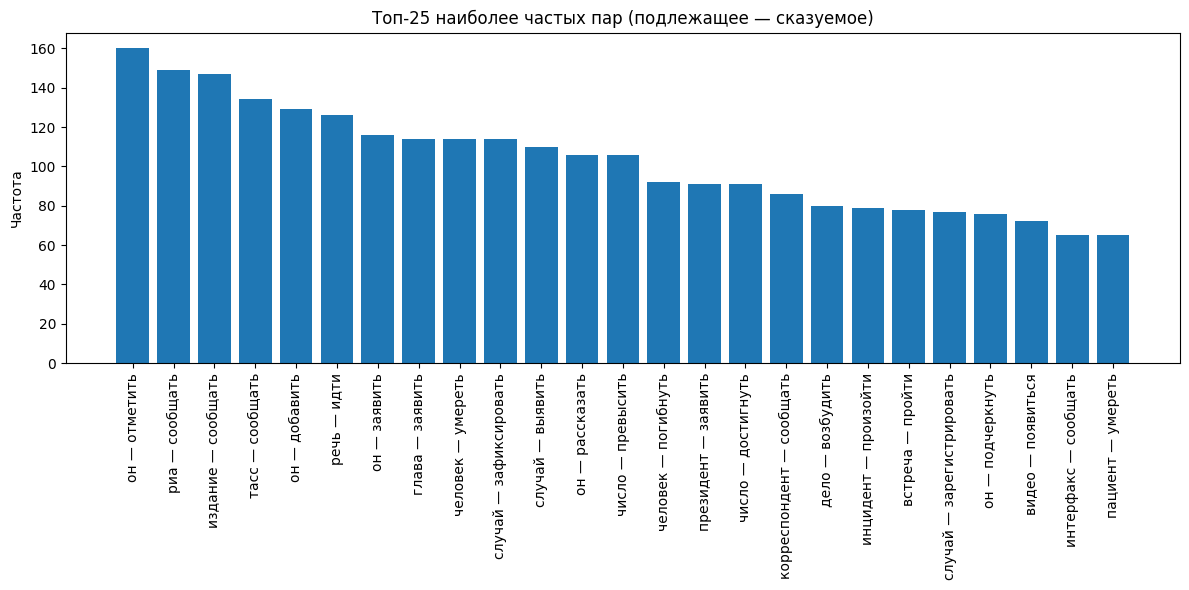


Результаты сохранены в файл 'subject_predicate_pairs.csv'


In [34]:
# Загрузка данных
texts = load_texts('/content/sample_data/news.csv', max_rows=5000)

# Проверка количества данных
if len(texts) < 100:
    print(f"Предупреждение: загружено всего {len(texts)} предложений.")
    print("минимум 1000 предложений.")

print(f"\nЗагружено предложений: {len(texts)}")

# Построение зависимостей
cooccurrences = build_cooccurrence_dependencies(
    texts,
    segmenter,
    morph_tagger,
    syntax_parser,
    morph
)

print(f"\nНайдено уникальных пар: {len(cooccurrences)}")

# Проверка перед выводом
if len(cooccurrences) == 0:
    print("⚠️ Не найдено ни одной пары подлежащее-сказуемое!")
else:
    # Вывод результатов
    print("\nТоп-10 наиболее частых сочетаний:")
    for (subject, predicate), count in cooccurrences.most_common(10):
        print(f"{subject} - {predicate}: {count}")

    # Визуализация
    top_n = min(25, len(cooccurrences))
    if top_n > 0:
        visualize_results(cooccurrences, top_n=top_n)

    # Сохранение результатов
    results_df = pd.DataFrame([
        {'Подлежащее': s, 'Сказуемое': p, 'Частота': c}
        for (s, p), c in cooccurrences.most_common(100)
    ])
    results_df.to_csv('subject_predicate_pairs.csv', index=False, encoding='utf-8-sig')
    print("\nРезультаты сохранены в файл 'subject_predicate_pairs.csv'")